          ОТЧЕТ ПО ЛИНЕЙНОЙ РЕГРЕССИИ (ВАРИАНТ 2)           
Показатель                               | Значение       
------------------------------------------------------------
Объем выборки (n)                        | 35             
Выборочное среднее x                     | 7.9810         
Выборочное среднее y                     | -2.6739        
------------------------------------------------------------
Коэффициент наклона (beta1_hat)          | -0.6366        
Свободный член (beta0_hat)               | 2.4065         
Уравнение регрессии                      | y = 2.41 + (-0.64)*x
------------------------------------------------------------
Остаточная сумма квадратов (RSS)         | 30.0737        
Оценка дисперсии ошибки (s^2)            | 0.9113         
Стандартная ошибка beta1 (SE)            | 0.0455         
------------------------------------------------------------
95% ДИ для beta1 (нижняя граница)        | -0.7291        
95% ДИ для beta1 (верхняя граница)       

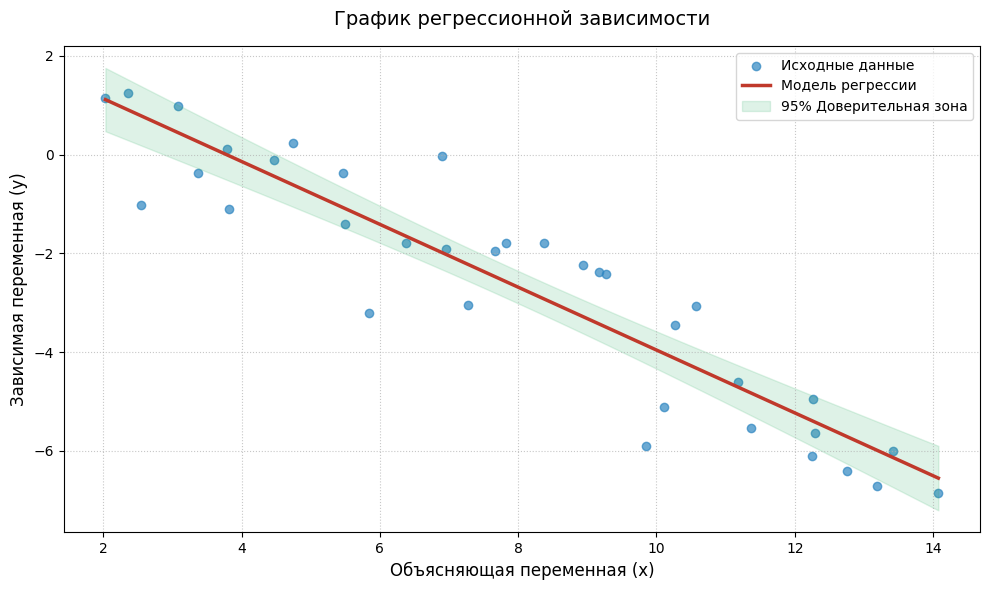

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Настройка вывода для удобства чтения
pd.set_option("display.precision", 4)

# --- 1. Загрузка данных из файла ---
filename = "variant_2_data.csv"
df = pd.read_csv(filename)
n = len(df)

# --- 2. Основные вычисления ---
x_mean, y_mean = df["x"].mean(), df["y"].mean()
Sxx = ((df["x"] - x_mean) ** 2).sum()
Sxy = ((df["x"] - x_mean) * (df["y"] - y_mean)).sum()

# Коэффициенты регрессии
beta1_hat = Sxy / Sxx
beta0_hat = y_mean - beta1_hat * x_mean

# Прогнозы и ошибки
df["y_hat"] = beta0_hat + beta1_hat * df["x"]
df["e"] = df["y"] - df["y_hat"]
RSS = (df["e"] ** 2).sum()
TSS = ((df["y"] - y_mean) ** 2).sum()
s2 = RSS / (n - 2)
s = np.sqrt(s2)
R2 = 1 - (RSS / TSS)

# Статистики и интервалы
alpha = 0.05
t_crit = stats.t.ppf(1 - alpha / 2, n - 2)
SE_beta1 = s / np.sqrt(Sxx)
ci_beta1 = (beta1_hat - t_crit * SE_beta1, beta1_hat + t_crit * SE_beta1)

print("=" * 60)
print(f"{'ОТЧЕТ ПО ЛИНЕЙНОЙ РЕГРЕССИИ (ВАРИАНТ 2)':^60}")
print("=" * 60)
print(f"{'Показатель':<40} | {'Значение':<15}")
print("-" * 60)
print(f"{'Объем выборки (n)':<40} | {n:<15}")
print(f"{'Выборочное среднее x':<40} | {x_mean:<15.4f}")
print(f"{'Выборочное среднее y':<40} | {y_mean:<15.4f}")
print("-" * 60)
print(f"{'Коэффициент наклона (beta1_hat)':<40} | {beta1_hat:<15.4f}")
print(f"{'Свободный член (beta0_hat)':<40} | {beta0_hat:<15.4f}")
print(f"{'Уравнение регрессии':<40} | y = {beta0_hat:.2f} + ({beta1_hat:.2f})*x")
print("-" * 60)
print(f"{'Остаточная сумма квадратов (RSS)':<40} | {RSS:<15.4f}")
print(f"{'Оценка дисперсии ошибки (s^2)':<40} | {s2:<15.4f}")
print(f"{'Стандартная ошибка beta1 (SE)':<40} | {SE_beta1:<15.4f}")
print("-" * 60)
print(f"{'95% ДИ для beta1 (нижняя граница)':<40} | {ci_beta1[0]:<15.4f}")
print(f"{'95% ДИ для beta1 (верхняя граница)':<40} | {ci_beta1[1]:<15.4f}")
print(f"{'Коэффициент детерминации (R^2)':<40} | {R2:<15.4f}")
print("=" * 60)

# --- 4. Построение графика ---
plt.figure(figsize=(10, 6), dpi=100)
plt.scatter(df["x"], df["y"], color="#2E86C1", alpha=0.7, label="Исходные данные")

# Отрисовка линии регрессии
x_plot = np.linspace(df["x"].min(), df["x"].max(), 100)
y_plot = beta0_hat + beta1_hat * x_plot
plt.plot(x_plot, y_plot, color="#C0392B", lw=2.5, label="Модель регрессии")

# Доверительный интервал (заливка)
SE_y_line = s * np.sqrt(1 / n + (x_plot - x_mean) ** 2 / Sxx)
plt.fill_between(
    x_plot,
    y_plot - t_crit * SE_y_line,
    y_plot + t_crit * SE_y_line,
    color="#27AE60",
    alpha=0.15,
    label="95% Доверительная зона",
)

plt.title("График регрессионной зависимости", fontsize=14, pad=15)
plt.xlabel("Объясняющая переменная (x)", fontsize=12)
plt.ylabel("Зависимая переменная (y)", fontsize=12)
plt.legend(frameon=True)
plt.grid(True, linestyle=":", alpha=0.7)
plt.tight_layout()
plt.show()